<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/01_LFW_FiftyOne_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — LFW con FiftyOne: 10 rostros reales


Prepara una muestra reproducible de 10 imágenes faciales reales del conjunto **Labeled Faces in the Wild (LFW)** mediante FiftyOne. Las imágenes y su manifest se almacenan en Google Drive dentro de la estructura común del proyecto `Investigacion_Deepfake_Watermarking_2026`.


In [ ]:
# ============================================================
# Instalación de dependencias
# ============================================================

%pip uninstall -y Pillow fiftyone fiftyone-brain fiftyone-db

%pip install --no-cache-dir "Pillow==12.3.0"
%pip install --no-cache-dir "fiftyone==1.21.0"

print()
print("============================================================")
print(" INSTALACIÓN COMPLETADA")
print("============================================================")
print()
print("Reinicia la sesión de Colab antes de continuar:")
print("Entorno de ejecución -> Reiniciar sesión")
print()
print("Después del reinicio, continúa desde la CELDA 2.")


Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
Found existing installation: fiftyone 1.21.0
Uninstalling fiftyone-1.21.0:
  Successfully uninstalled fiftyone-1.21.0
Found existing installation: fiftyone-brain 0.24.0
Uninstalling fiftyone-brain-0.24.0:
  Successfully uninstalled fiftyone-brain-0.24.0
Found existing installation: fiftyone_db 1.4.1
Uninstalling fiftyone_db-1.4.1:
  Successfully uninstalled fiftyone_db-1.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 178.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 304.2 MB/s eta 0:00:00
  Created wheel for fiftyone-db: filename=fiftyone_db-1.4.1-py3-none-manylinux1_x86_64.whl size=59387757 sha256=999ea333fdd75daaa5a107675

In [ ]:
# ============================================================
# Verificación del entorno
# ============================================================

import sys
import PIL
from PIL import Image

import fiftyone as fo
import fiftyone.zoo as foz

print("============================================================")
print(" VERIFICACIÓN DEL ENTORNO")
print("============================================================")
print(f"Python:    {sys.version.split()[0]}")
print(f"Pillow:    {PIL.__version__}")
print(f"FiftyOne:  {fo.__version__}")
print()
print("✓ Entorno listo.")


 VERIFICACIÓN DEL ENTORNO
Python:    3.13.15
Pillow:    12.3.0
FiftyOne:  1.21.0

✓ Entorno listo.


In [ ]:
# ============================================================
# Google Drive y rutas del proyecto
# ============================================================

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
)

IMAGE_DIR = ROOT / "datasets/real/lfw/smoke_10/images"
MANIFEST_DIR = ROOT / "datasets/real/lfw/smoke_10/manifests"
METADATA_FILE = MANIFEST_DIR / "metadata.csv"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("============================================================")
print(" RUTAS DEL PROYECTO")
print("============================================================")
print(f"ROOT:          {ROOT}")
print(f"Imágenes:      {IMAGE_DIR}")
print(f"Manifest:      {METADATA_FILE}")


Mounted at /content/drive
 RUTAS DEL PROYECTO
ROOT:          /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026
Imágenes:      /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/images
Manifest:      /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/manifests/metadata.csv


In [ ]:
# ============================================================
# Configuración de la muestra
# ============================================================

import shutil
import hashlib
import pandas as pd

N_IMAGES = 10
SEED = 2026
SPLIT = "test"
DATASET_NAME = f"lfw-{SPLIT}-smoke-{N_IMAGES}-{SEED}"

# Preparar una salida limpia y reproducible
if IMAGE_DIR.exists():
    shutil.rmtree(IMAGE_DIR)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

if METADATA_FILE.exists():
    METADATA_FILE.unlink()

# Evitar conflictos si la celda se ejecuta más de una vez
if fo.dataset_exists(DATASET_NAME):
    fo.delete_dataset(DATASET_NAME)

print("============================================================")
print(" CONFIGURACIÓN")
print("============================================================")
print("Dataset:          Labeled Faces in the Wild (LFW)")
print(f"Split:            {SPLIT}")
print(f"Número imágenes:  {N_IMAGES}")
print(f"Semilla:          {SEED}")
print(f"Tipo de muestra:  real")


 CONFIGURACIÓN
Dataset:          Labeled Faces in the Wild (LFW)
Split:            test
Número imágenes:  10
Semilla:          2026
Tipo de muestra:  real


In [ ]:
# ============================================================
# Cargar una muestra reproducible de LFW
# ============================================================

print("Cargando imágenes de LFW...")
print()

dataset = foz.load_zoo_dataset(
    "lfw",
    split=SPLIT,
    dataset_name=DATASET_NAME,
    shuffle=True,
    seed=SEED,
    max_samples=N_IMAGES,
)

print()
print("============================================================")
print(" MUESTRA CARGADA")
print("============================================================")
print(f"Imágenes cargadas: {len(dataset)}")

assert len(dataset) == N_IMAGES, (
    f"Se esperaban {N_IMAGES} imágenes, "
    f"pero FiftyOne cargó {len(dataset)}."
)


Cargando imágenes de LFW...



INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/lfw/test'


INFO:fiftyone.utils.lfw:Downloading dataset to '/root/fiftyone/lfw/tmp-download/lfw.tgz'
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ndownloader.figshare.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 's3-eu-west-1.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


 100% |██████|    1.3Gb/1.3Gb [5.4s elapsed, 0s remaining, 282.9Mb/s]      


INFO:eta.core.utils: 100% |██████|    1.3Gb/1.3Gb [5.4s elapsed, 0s remaining, 282.9Mb/s]      


...

 100% |███████████████████| 10/10 [37.8ms elapsed, 0s remaining, 264.4 samples/s]     


INFO:eta.core.utils: 100% |███████████████████| 10/10 [37.8ms elapsed, 0s remaining, 264.4 samples/s]     


Dataset 'lfw-test-smoke-10-2026' created


INFO:fiftyone.zoo.datasets:Dataset 'lfw-test-smoke-10-2026' created



 MUESTRA CARGADA
Imágenes cargadas: 10


In [ ]:
# ============================================================
# Organizar imágenes y construir metadatos
# ============================================================

records = []
samples = list(dataset)

for i, sample in enumerate(samples, start=1):

    source_path = Path(sample.filepath)
    source_id = source_path.stem

    # Identidad disponible en LFW
    person = None

    try:
        ground_truth = sample["ground_truth"]
        if ground_truth is not None and hasattr(ground_truth, "label"):
            person = ground_truth.label
    except Exception:
        pass

    if not person:
        person = source_path.parent.name.replace("_", " ")

    extension = source_path.suffix.lower()

    if extension not in [".jpg", ".jpeg", ".png"]:
        extension = ".jpg"

    filename = f"real_{i:03d}{extension}"
    destination_path = IMAGE_DIR / filename

    # Conservar el archivo original sin redimensionar ni recomprimir
    shutil.copy2(source_path, destination_path)

    with Image.open(destination_path) as img:
        width, height = img.size
        mode = img.mode

    with open(destination_path, "rb") as f:
        sha256 = hashlib.sha256(f.read()).hexdigest()

    records.append({
        "index": i,
        "filename": filename,
        "class_label": "real",
        "source_dataset": "LFW",
        "person": person,
        "source_id": source_id,
        "width": width,
        "height": height,
        "mode": mode,
        "split": SPLIT,
        "seed": SEED,
        "sha256": sha256,
    })

print("============================================================")
print(" IMÁGENES ORGANIZADAS")
print("============================================================")

for r in records:
    print(
        f"{r['index']:02d} | "
        f"{r['filename']} | "
        f"{r['width']}x{r['height']} | "
        f"{r['person']}"
    )


 IMÁGENES ORGANIZADAS
01 | real_001.jpg | 250x250 | Elizabeth_Smart
02 | real_002.jpg | 250x250 | Thaksin_Shinawatra
03 | real_003.jpg | 250x250 | Jenna_Elfman
04 | real_004.jpg | 250x250 | Tommy_Haas
05 | real_005.jpg | 250x250 | Shannon_OBrien
06 | real_006.jpg | 250x250 | Ian_Thorpe
07 | real_007.jpg | 250x250 | Yoriko_Kawaguchi
08 | real_008.jpg | 250x250 | Christopher_Reeve
09 | real_009.jpg | 250x250 | Gene_Robinson
10 | real_010.jpg | 250x250 | Robert_Redford


In [ ]:
# ============================================================
# Guardar manifest
# ============================================================

df = pd.DataFrame(records)

df.to_csv(
    METADATA_FILE,
    index=False
)

print("============================================================")
print(" MANIFEST")
print("============================================================")
print(f"Archivo: {METADATA_FILE}")
print()
display(df)


 MANIFEST
Archivo: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/manifests/metadata.csv



,index,filename,class_label,source_dataset,person,source_id,width,height,mode,split,seed,sha256
0,1,real_001.jpg,real,LFW,Elizabeth_Smart,Elizabeth_Smart_0002,250,250,RGB,test,2026,c41526beca61431d9bfcd41cf0e35e51c9c287fce79c11...
1,2,real_002.jpg,real,LFW,Thaksin_Shinawatra,Thaksin_Shinawatra_0002,250,250,RGB,test,2026,f9d2a7994e4a9743dad75c0e2f54d600186b886b144b3d...
2,3,real_003.jpg,real,LFW,Jenna_Elfman,Jenna_Elfman_0001,250,250,RGB,test,2026,9c2bf4ae1bc881cf58e7b33f4736db8a1c1618b5aa644e...
3,4,real_004.jpg,real,LFW,Tommy_Haas,Tommy_Haas_0002,250,250,RGB,test,2026,35e511129b8ab0fee5ec40ba30cfee20c7090be5b935e8...
4,5,real_005.jpg,real,LFW,Shannon_OBrien,Shannon_OBrien_0002,250,250,RGB,test,2026,0318d51cca8cb7a68d65a05c5c31806e4ac685d501cbd5...
5,6,real_006.jpg,real,LFW,Ian_Thorpe,Ian_Thorpe_0004,250,250,RGB,test,2026,ed361f533b3c98853e1a5097c2f7fdb781ca6f6e402fc3...
6,7,real_007.jpg,real,LFW,Yoriko_Kawaguchi,Yoriko_Kawaguchi_0003,250,250,RGB,test,2026,7a6750dea2f0fa5ccdc067cdf766bf3bcdaa38b08e01a2...
7,8,real_008.jpg,real,LFW,Christopher_Reeve,Christopher_Reeve_0004,250,250,RGB,test,2026,f6bae23ebed089267a417aa2d742efe6b8974267487212...
8,9,real_009.jpg,real,LFW,Gene_Robinson,Gene_Robinson_0004,250,250,RGB,test,2026,58fee64f7fbd8a4c7e77e1b7c078e66b517150caffdc69...
9,10,real_010.jpg,real,LFW,Robert_Redford,Robert_Redford_0006,250,250,RGB,test,2026,cae2fa053fcb3e7dc3b2e4f8ca19dfe199babd8e2c12c8...


In [ ]:
# ============================================================
# Verificación de integridad
# ============================================================

image_files = sorted([
    p for p in IMAGE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("============================================================")
print(" VERIFICACIÓN")
print("============================================================")
print(f"Esperadas:    {N_IMAGES}")
print(f"Encontradas:  {len(image_files)}")
print()

assert len(image_files) == N_IMAGES, (
    f"Se esperaban {N_IMAGES} imágenes "
    f"pero se encontraron {len(image_files)}."
)

for path in image_files:
    with Image.open(path) as img:
        img.verify()
    print(f"✓ {path.name}")

assert df["sha256"].nunique() == N_IMAGES, (
    "Se detectaron archivos duplicados en la muestra."
)

print()
print("✓ Las imágenes fueron verificadas correctamente.")


 VERIFICACIÓN
Esperadas:    10
Encontradas:  10

✓ real_001.jpg
✓ real_002.jpg
✓ real_003.jpg
✓ real_004.jpg
✓ real_005.jpg
✓ real_006.jpg
✓ real_007.jpg
✓ real_008.jpg
✓ real_009.jpg
✓ real_010.jpg

✓ Las imágenes fueron verificadas correctamente.


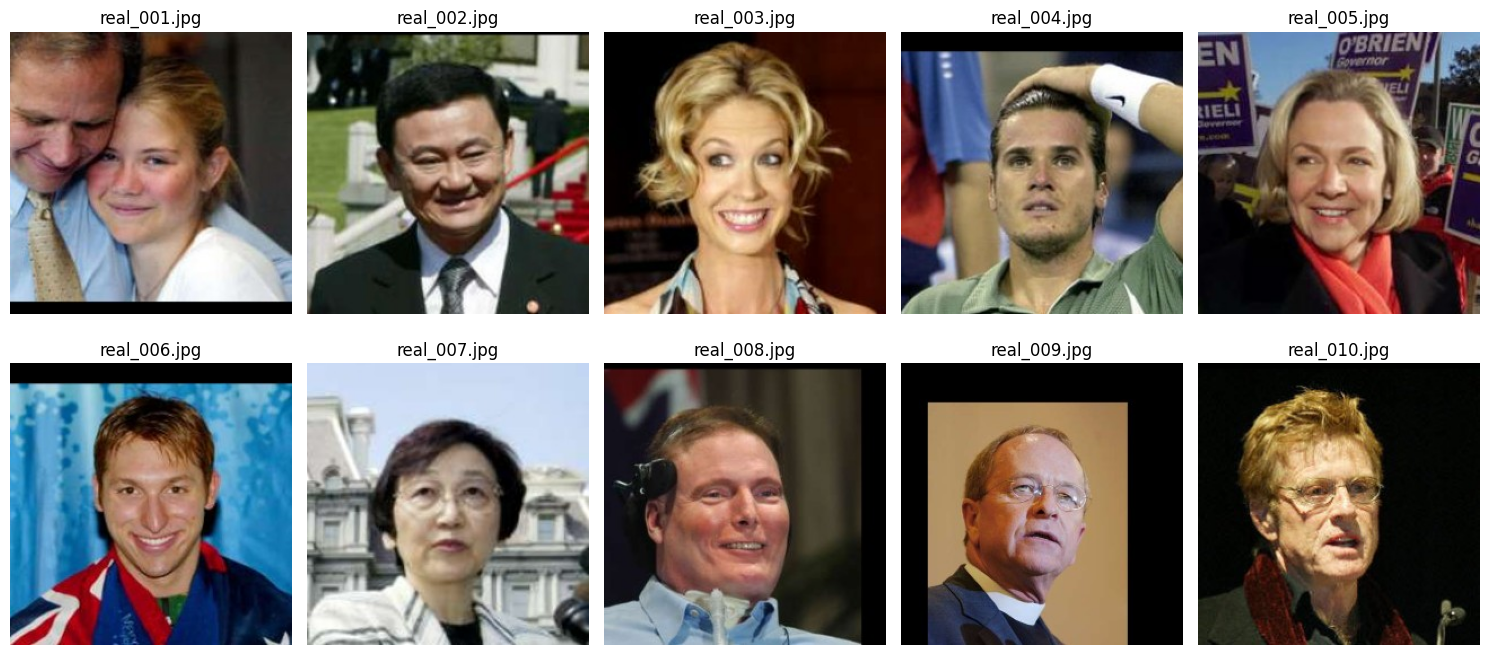

In [ ]:
# ============================================================
# Visualización de la muestra
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for ax, image_path in zip(axes, image_files):
    with Image.open(image_path) as img:
        ax.imshow(img.convert("RGB"))

    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Resumen
# ============================================================

print("============================================================")
print(" 01_LFW_FiftyOne_10 COMPLETADO")
print("============================================================")
print()
print("Dataset fuente:     Labeled Faces in the Wild (LFW)")
print(f"Split:              {SPLIT}")
print(f"Clase del proyecto: real")
print(f"Imágenes:           {len(image_files)}")
print(f"Semilla:            {SEED}")
print()
print("Carpeta de imágenes:")
print(f"  {IMAGE_DIR}")
print()
print("Manifest:")
print(f"  {METADATA_FILE}")
print()
print("✓ Muestra de rostros reales preparada para el pipeline del proyecto.")


 01_LFW_FiftyOne_10 COMPLETADO

Dataset fuente:     Labeled Faces in the Wild (LFW)
Split:              test
Clase del proyecto: real
Imágenes:           10
Semilla:            2026

Carpeta de imágenes:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/images

Manifest:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/manifests/metadata.csv

✓ Muestra de rostros reales preparada para el pipeline del proyecto.
